# フリッカ雑音（1/f 雑音）トイモデル

フリッカ雑音（flicker noise）は、低周波で強くなる **1/f 型**の雑音です。
多くの物理系で観測されますが、原因は系によって様々で、単純な「1つの時定数」では説明しきれないことが多いです。

## トイモデル（周波数領域で 1/f^α を作る）
白色雑音をフーリエ変換し、周波数ごとに振幅を `1/f^(α/2)` で重み付けして逆変換します。
するとパワースペクトル密度（PSD）が概ね `S(f) ∝ 1/f^α` になる時系列が得られます。

## 見るポイント
- 時間波形は「ゆっくり大きく揺れる」成分が目立つ
- PSD を log-log で見ると、低周波側が `≈ 1/f` の傾きになる

（※定性的理解用の簡易生成です。厳密な統計性は用途に応じて調整が必要です。）


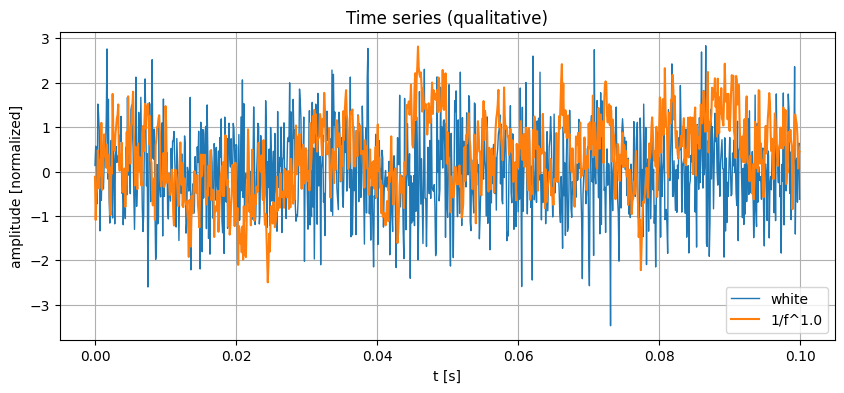

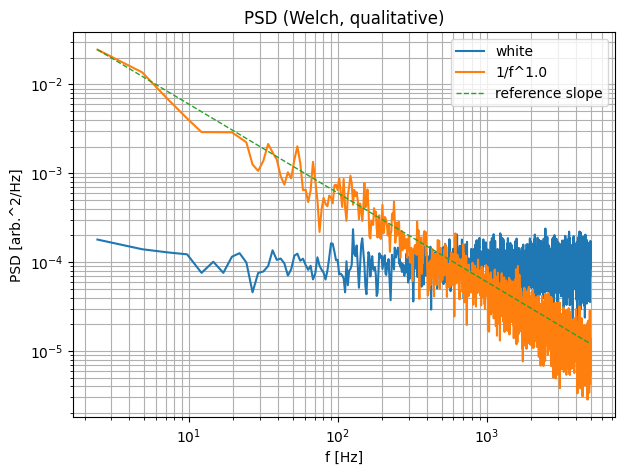

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def colored_noise_1_over_f(alpha, N, fs, rng):
    """周波数領域で 1/f^alpha に整形した実信号を生成（定性的）"""
    # rFFT 側の周波数
    f = np.fft.rfftfreq(N, d=1.0 / fs)

    # 複素ガウス雑音（周波数領域）
    re = rng.normal(size=len(f))
    im = rng.normal(size=len(f))
    X = re + 1j * im

    # DC 成分は 0 にする（1/f が発散するため）
    X[0] = 0.0

    # 1/f^(alpha/2) で振幅を整形（PSD が 1/f^alpha になる）
    w = np.ones_like(f)
    nz = f > 0
    w[nz] = 1.0 / (f[nz] ** (alpha / 2.0))
    X = X * w

    x = np.fft.irfft(X, n=N)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def welch_psd(x, fs, nperseg=4096, noverlap=2048):
    x = np.asarray(x)
    step = nperseg - noverlap
    if step <= 0:
        raise ValueError("noverlap must be < nperseg")
    w = np.hanning(nperseg)
    scale = fs * (w**2).sum()
    psd = None
    count = 0
    for start in range(0, len(x) - nperseg + 1, step):
        seg = x[start : start + nperseg]
        seg = seg - seg.mean()
        X = np.fft.rfft(seg * w)
        P = (np.abs(X) ** 2) / scale
        psd = P if psd is None else (psd + P)
        count += 1
    psd = psd / max(count, 1)
    f = np.fft.rfftfreq(nperseg, d=1.0 / fs)
    return f, psd

# ===== パラメータ =====
fs = 10_000.0
T = 2.0
N = int(fs * T)

alpha = 1.0   # 1/f^alpha（alpha=1 がフリッカ）

rng = np.random.default_rng(0)

x_flicker = colored_noise_1_over_f(alpha=alpha, N=N, fs=fs, rng=rng)
x_white = rng.normal(size=N)
x_white = (x_white - x_white.mean()) / (x_white.std() + 1e-12)

t = np.arange(N) / fs

# ===== 時間波形（冒頭だけ） =====
plt.figure(figsize=(10, 4))
m = int(0.05 * N)
plt.plot(t[:m], x_white[:m], lw=1, label="white")
plt.plot(t[:m], x_flicker[:m], lw=1.5, label=f"1/f^{alpha}")
plt.xlabel("t [s]")
plt.ylabel("amplitude [normalized]")
plt.title("Time series (qualitative)")
plt.grid(True)
plt.legend()
plt.show()

# ===== PSD 比較 =====
f, P_white = welch_psd(x_white, fs)
f, P_flick = welch_psd(x_flicker, fs)

plt.figure(figsize=(7, 5))
plt.loglog(f[1:], P_white[1:], label="white")
plt.loglog(f[1:], P_flick[1:], label=f"1/f^{alpha}")

# 参照線: 1/f^alpha（形だけ）
ref = P_flick[1] * (f[1:] / f[1]) ** (-alpha)
plt.loglog(f[1:], ref, "--", lw=1, label="reference slope")

plt.xlabel("f [Hz]")
plt.ylabel("PSD [arb.^2/Hz]")
plt.title("PSD (Welch, qualitative)")
plt.grid(True, which="both")
plt.legend()
plt.show()
